In [17]:
import os, json
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random
import re

In [18]:
DATA_DIR = "./../code_classification_dataset"   # folder containing your .json files


In [19]:

# OUT_FILE = "label_index.json"

# CHOSEN_LABELS = {
#     "math", "graphs", "strings", "number theory",
#     "trees", "geometry", "games", "probabilities"
# }

# label_to_files = defaultdict(set)  # tag -> set of filenames
# others = set()                     # files with no chosen tag at all

# for fname in sorted(os.listdir(DATA_DIR)):
#     if not fname.endswith(".json"):
#         continue
#     path = os.path.join(DATA_DIR, fname)
#     with open(path, "r", encoding="utf-8") as f:
#         rec = json.load(f)

#     tags = rec.get("tags", [])
#     matched = [t for t in tags if t in CHOSEN_LABELS]

#     if matched:
#         for tag in matched:
#             label_to_files[tag].add(fname)
#     else:
#         others.add(fname)

# # Build final structure
# index = {}
# for label in CHOSEN_LABELS:
#     files = sorted(label_to_files[label])
#     index[label] = {"files": files, "count": len(files)}

# index["others"] = {"files": sorted(others), "count": len(others)}

# with open(OUT_FILE, "w") as f:
#     json.dump(index, f, indent=2)

# print(f"Saved → {OUT_FILE}\n")
# for label, info in index.items():
#     print(f"  {label:<20} {info['count']} files")

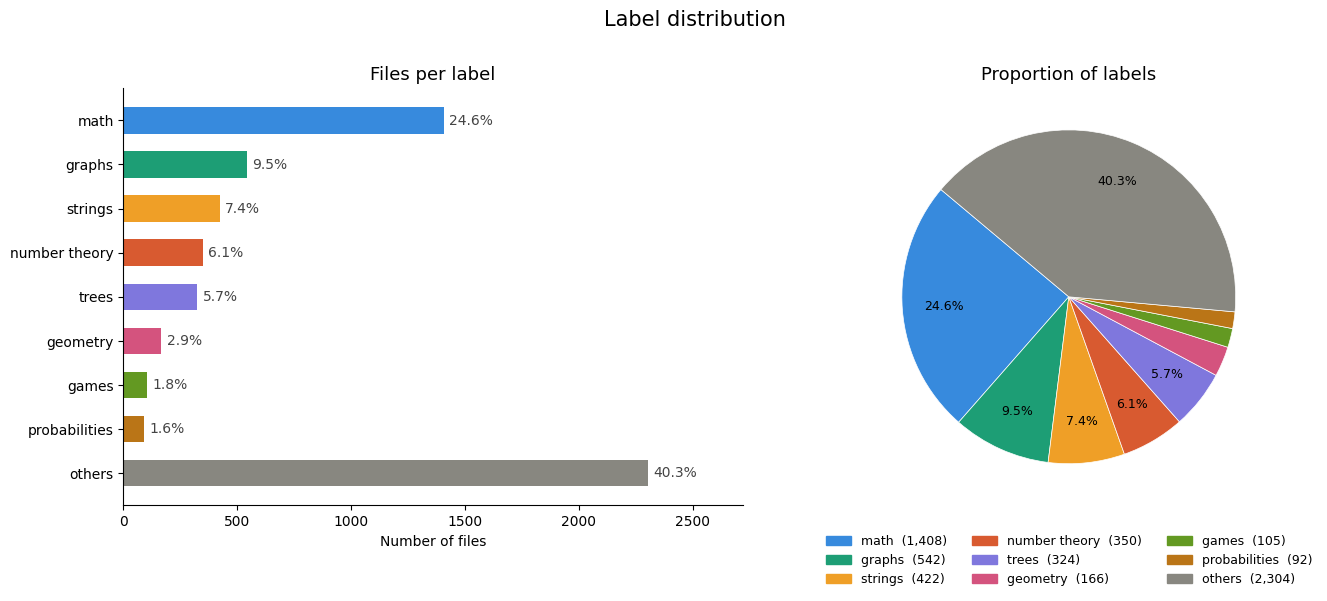


Total files indexed: 5,713
  math                 1,408  (24.6%)
  graphs                 542  (9.5%)
  strings                422  (7.4%)
  number theory          350  (6.1%)
  trees                  324  (5.7%)
  geometry               166  (2.9%)
  games                  105  (1.8%)
  probabilities           92  (1.6%)
  others               2,304  (40.3%)


In [20]:


with open("label_index.json") as f:
    index = json.load(f)

labels = list(index.keys())
counts = [index[lbl]["count"] for lbl in labels]
total = sum(counts)
percentages = [c / total * 100 for c in counts]

# ── sort by count descending, keep "others" last ──────────────────────────
order = sorted(
    range(len(labels)),
    key=lambda i: (labels[i] == "others", -counts[i])
)
labels      = [labels[i] for i in order]
counts      = [counts[i] for i in order]
percentages = [percentages[i] for i in order]

colors = [
    "#378ADD", "#1D9E75", "#EF9F27", "#D85A30",
    "#7F77DD", "#D4537E", "#639922", "#BA7517",
    "#888780",  # others → gray
]
colors = colors[:len(labels)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Label distribution", fontsize=15, fontweight="500", y=1.01)

# ── Bar chart ─────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(labels[::-1], counts[::-1], color=colors[::-1], height=0.6)
ax.set_xlabel("Number of files")
ax.set_title("Files per label", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
for bar, pct in zip(bars, percentages[::-1]):
    ax.text(
        bar.get_width() + max(counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center", fontsize=10, color="#444"
    )
ax.set_xlim(0, max(counts) * 1.18)

# ── Pie chart ─────────────────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
)
for t in autotexts:
    t.set_fontsize(9)
ax2.set_title("Proportion of labels", fontsize=13)
legend_patches = [
    mpatches.Patch(color=colors[i], label=f"{labels[i]}  ({counts[i]:,})")
    for i in range(len(labels))
]
ax2.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=9,
    frameon=False,
)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTotal files indexed: {total:,}")
for lbl, cnt, pct in zip(labels, counts, percentages):
    print(f"  {lbl:<20} {cnt:>5,}  ({pct:.1f}%)")

In [15]:
LABEL_TO_ID = {
    "math":          0,
    "graphs":        1,
    "strings":       2,
    "number theory": 3,
    "trees":         4,
    "geometry":      5,
    "games":         6,
    "probabilities": 7,
}

COLORS = [
    "#378ADD", "#1D9E75", "#EF9F27", "#D85A30",
    "#7F77DD", "#D4537E", "#639922", "#BA7517",
]

def fetch_files_per_label(label, randomize=True, N=None):
    with open("label_index.json", "r", encoding="utf-8") as f:
        index = json.load(f)
    files = index[label]["files"]
    if randomize : random.shuffle(files)
    if N == None : return files
    return files[:min(N, len(files))]

In [14]:
## Lenght statistics : 

def preprocess_code(code: str) -> str:
    """
    Clean raw code string.
    Handles Windows line endings, tabs, excessive blank lines.
    """
    code = code.replace('\r\n', '\n').replace('\r', '\n')
    code = code.replace('\t', '    ')
    code = re.sub(r'#[^\n]*', '', code)
    code = '\n'.join(line.rstrip() for line in code.split('\n'))
    code = re.sub(r'\n{3,}', '\n\n', code)
    code = code.strip()
    return code

def compute_length_stats(domain, log = False, preprocess = False):
    all_lengths = []   # (label, length) for every file
    label_stats = {}

    for label in LABEL_TO_ID:
        files = fetch_files_per_label(label)
        lengths = []
        for fname in files:
            with open(os.path.join(DATA_DIR, fname),encoding="utf-8") as f:
                rec = json.load(f)
            text = rec.get(domain, "") or ""
            if preprocess : text = preprocess_code(text)
            lengths.append(len(text.split()))

        lengths = np.array(lengths)
        label_stats[label] = {
            "mean":   lengths.mean(),
            "std":    lengths.std(),
            "min":    lengths.min(),
            "max":    lengths.max(),
            "count":  len(lengths),
        }
        all_lengths.extend([(label, l) for l in lengths])

    # ── overall stats ─────────────────────────────────────────────────────
    all_values = np.array([l for _, l in all_lengths])
    overall = {
        "mean": all_values.mean(),
        "std":  all_values.std(),
        "min":  all_values.min(),
        "max":  all_values.max(),
        "count": len(all_values),
    }

    # ── print ─────────────────────────────────────────────────────────────
    print(f"\nDomain: {domain}")
    print(f"{'label':<18} {'count':>6} {'mean':>8} {'std':>8} {'min':>6} {'max':>6}")
    print("-" * 56)
    for label, s in label_stats.items():
        print(f"{label:<18} {s['count']:>6} {s['mean']:>8.1f} {s['std']:>8.1f} {s['min']:>6} {s['max']:>6}")
    print("-" * 56)
    print(f"{'OVERALL':<18} {overall['count']:>6} {overall['mean']:>8.1f} {overall['std']:>8.1f} {overall['min']:>6} {overall['max']:>6}")

    # ── scatter ───────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Length statistics — {domain}", fontsize=13)

    ax = axes[0]
    for label, label_id in LABEL_TO_ID.items():
        lengths = [l for lbl, l in all_lengths if lbl == label]
        x = np.random.normal(label_id, 0.15, size=len(lengths))  # jitter
        s = label_stats[label]
        ax.scatter(x, lengths, c=COLORS[label_id], alpha=0.4, s=12, label=f"{label} ({s["mean"]:.0f})")
        ax.errorbar(label_id, s["mean"], yerr=s["std"],
                    fmt="D", color="black", markersize=5, linewidth=1.5, zorder=5)

    ax.axhline(overall["mean"], color="red", linestyle="--", linewidth=1, label=f"overall mean ({overall['mean']:.0f})")
    ax.set_xticks(list(LABEL_TO_ID.values()))
    ax.set_xticklabels(list(LABEL_TO_ID.keys()), rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Number of words")
    ax.set_title("Scatter + mean ± std per label")
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)


    # ── box plot ──────────────────────────────────────────────────────────
    ax2 = axes[1]
    data_per_label = [[l for lbl, l in all_lengths if lbl == label]
                      for label in LABEL_TO_ID]
    bp = ax2.boxplot(data_per_label, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.axhline(overall["mean"], color="red", linestyle="--", linewidth=1)
    ax2.set_xticks(range(1, len(LABEL_TO_ID) + 1))
    ax2.set_xticklabels(list(LABEL_TO_ID.keys()), rotation=30, ha="right", fontsize=9)
    ax2.set_ylabel("Number of words")
    ax2.set_title("Box plot per label")
    ax2.spines[["top", "right"]].set_visible(False)

    if log :
        ax.set_yscale("log")
        ax2.set_yscale("log")


    plt.tight_layout()
    plt.savefig(f"length_stats_{domain}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved → length_stats_{domain}.png")

    return all_lengths, label_stats, overall



Domain: prob_desc_description
label               count     mean      std    min    max
--------------------------------------------------------
math                 1408    152.9     73.7     25    563
graphs                542    182.8     84.2     31    631
strings               422    161.0     69.7     29    447
number theory         350    133.0     67.1     26    380
trees                 324    184.0     79.3     35    511
geometry              166    163.4     85.1     11    540
games                 105    188.6     75.6     59    422
probabilities          92    200.2     98.1     60    576
--------------------------------------------------------
OVERALL              3409    162.4     78.2     11    631


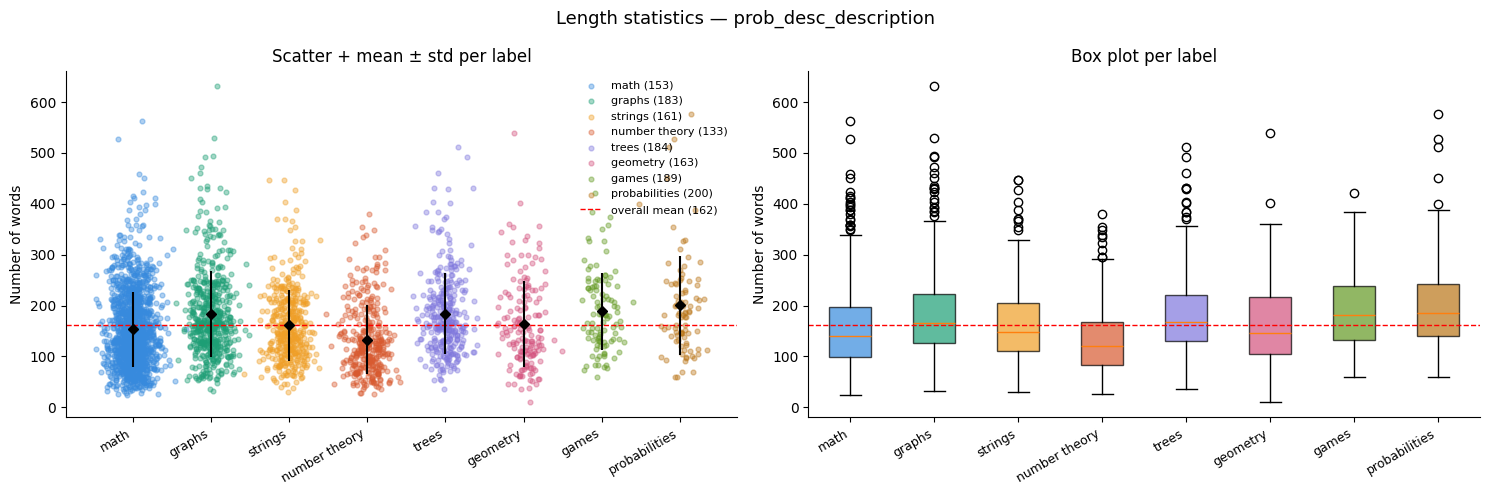


Saved → length_stats_prob_desc_description.png


([('math', np.int64(105)),
  ('math', np.int64(168)),
  ('math', np.int64(44)),
  ('math', np.int64(93)),
  ('math', np.int64(96)),
  ('math', np.int64(130)),
  ('math', np.int64(104)),
  ('math', np.int64(233)),
  ('math', np.int64(68)),
  ('math', np.int64(81)),
  ('math', np.int64(207)),
  ('math', np.int64(178)),
  ('math', np.int64(88)),
  ('math', np.int64(139)),
  ('math', np.int64(116)),
  ('math', np.int64(204)),
  ('math', np.int64(236)),
  ('math', np.int64(151)),
  ('math', np.int64(52)),
  ('math', np.int64(66)),
  ('math', np.int64(164)),
  ('math', np.int64(398)),
  ('math', np.int64(108)),
  ('math', np.int64(181)),
  ('math', np.int64(115)),
  ('math', np.int64(172)),
  ('math', np.int64(279)),
  ('math', np.int64(99)),
  ('math', np.int64(134)),
  ('math', np.int64(40)),
  ('math', np.int64(192)),
  ('math', np.int64(229)),
  ('math', np.int64(230)),
  ('math', np.int64(93)),
  ('math', np.int64(125)),
  ('math', np.int64(195)),
  ('math', np.int64(69)),
  ('math', np

In [5]:
compute_length_stats("prob_desc_description")


Domain: source_code
label               count     mean      std    min    max
--------------------------------------------------------
math                 1408    128.6    214.5      2   5075
graphs                542    188.5    168.6     11   1967
strings               422    124.3    149.2      3   1628
number theory         350    161.3    308.0      6   3990
trees                 324    224.4    314.0      9   4950
geometry              166    161.6    244.2      4   2600
games                 105    115.3    137.5      5    868
probabilities          92    163.8    168.1      2   1014
--------------------------------------------------------
OVERALL              3409    152.2    225.2      2   5075


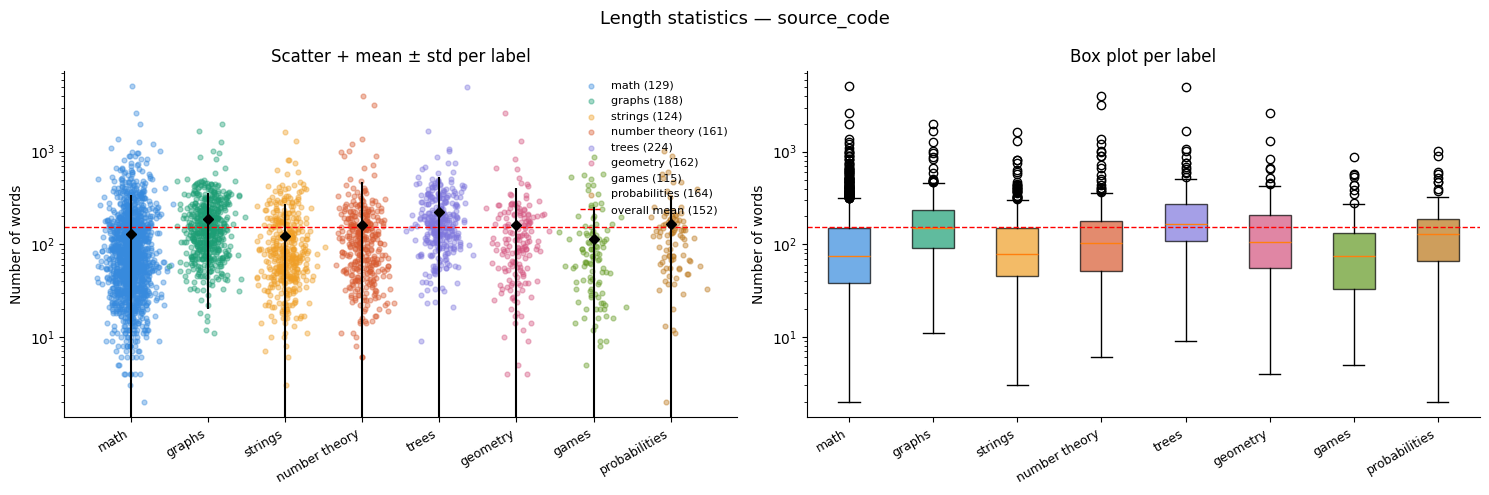


Saved → length_stats_source_code.png


([('math', np.int64(9)),
  ('math', np.int64(24)),
  ('math', np.int64(56)),
  ('math', np.int64(184)),
  ('math', np.int64(37)),
  ('math', np.int64(128)),
  ('math', np.int64(88)),
  ('math', np.int64(81)),
  ('math', np.int64(48)),
  ('math', np.int64(102)),
  ('math', np.int64(243)),
  ('math', np.int64(129)),
  ('math', np.int64(123)),
  ('math', np.int64(151)),
  ('math', np.int64(69)),
  ('math', np.int64(166)),
  ('math', np.int64(205)),
  ('math', np.int64(365)),
  ('math', np.int64(43)),
  ('math', np.int64(169)),
  ('math', np.int64(45)),
  ('math', np.int64(544)),
  ('math', np.int64(37)),
  ('math', np.int64(102)),
  ('math', np.int64(58)),
  ('math', np.int64(188)),
  ('math', np.int64(50)),
  ('math', np.int64(163)),
  ('math', np.int64(28)),
  ('math', np.int64(54)),
  ('math', np.int64(42)),
  ('math', np.int64(21)),
  ('math', np.int64(7)),
  ('math', np.int64(86)),
  ('math', np.int64(165)),
  ('math', np.int64(79)),
  ('math', np.int64(41)),
  ('math', np.int64(33))

In [23]:
compute_length_stats("source_code", log=True, preprocess=True)


Domain: prob_desc_input_spec
label               count     mean      std    min    max
--------------------------------------------------------
math                 1408     65.2     35.1      0    403
graphs                542     96.0     43.6      0    331
strings               422     68.8     35.9      0    310
number theory         350     57.5     30.4      0    175
trees                 324     93.3     39.7      0    237
geometry              166     75.1     42.6      0    220
games                 105     64.6     28.2      0    147
probabilities          92     63.1     33.7      0    183
--------------------------------------------------------
OVERALL              3409     72.8     39.2      0    403


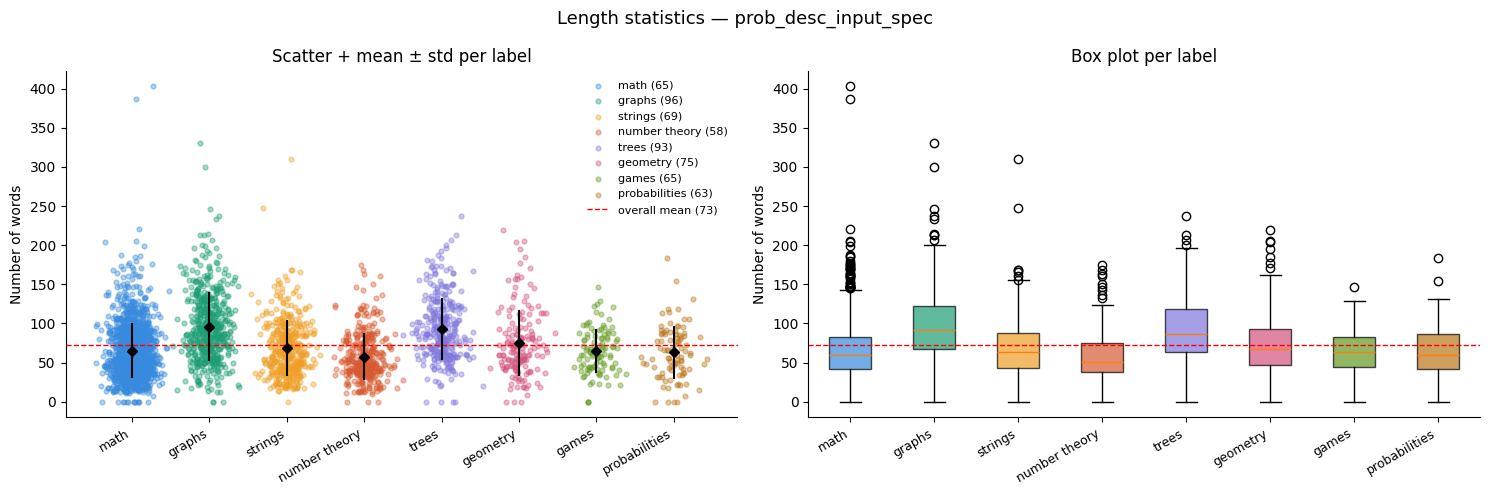


Saved → length_stats_prob_desc_input_spec.png


([('math', np.int64(60)),
  ('math', np.int64(39)),
  ('math', np.int64(53)),
  ('math', np.int64(51)),
  ('math', np.int64(58)),
  ('math', np.int64(48)),
  ('math', np.int64(81)),
  ('math', np.int64(38)),
  ('math', np.int64(35)),
  ('math', np.int64(23)),
  ('math', np.int64(16)),
  ('math', np.int64(89)),
  ('math', np.int64(44)),
  ('math', np.int64(84)),
  ('math', np.int64(72)),
  ('math', np.int64(55)),
  ('math', np.int64(46)),
  ('math', np.int64(153)),
  ('math', np.int64(43)),
  ('math', np.int64(67)),
  ('math', np.int64(81)),
  ('math', np.int64(39)),
  ('math', np.int64(79)),
  ('math', np.int64(60)),
  ('math', np.int64(42)),
  ('math', np.int64(93)),
  ('math', np.int64(112)),
  ('math', np.int64(38)),
  ('math', np.int64(112)),
  ('math', np.int64(0)),
  ('math', np.int64(46)),
  ('math', np.int64(36)),
  ('math', np.int64(0)),
  ('math', np.int64(51)),
  ('math', np.int64(45)),
  ('math', np.int64(40)),
  ('math', np.int64(148)),
  ('math', np.int64(24)),
  ('math',

In [7]:
compute_length_stats("prob_desc_input_spec")


Domain: prob_desc_notes
label               count     mean      std    min    max
--------------------------------------------------------
math                 1408     60.9     58.9      0    551
graphs                542     53.9     55.1      0    316
strings               422     48.3     47.1      0    282
number theory         350     57.0     59.7      0    551
trees                 324     57.7     61.6      0    365
geometry              166     39.3     39.9      0    177
games                 105     67.9     57.1      0    332
probabilities          92     65.1     67.7      0    246
--------------------------------------------------------
OVERALL              3409     56.8     57.0      0    551


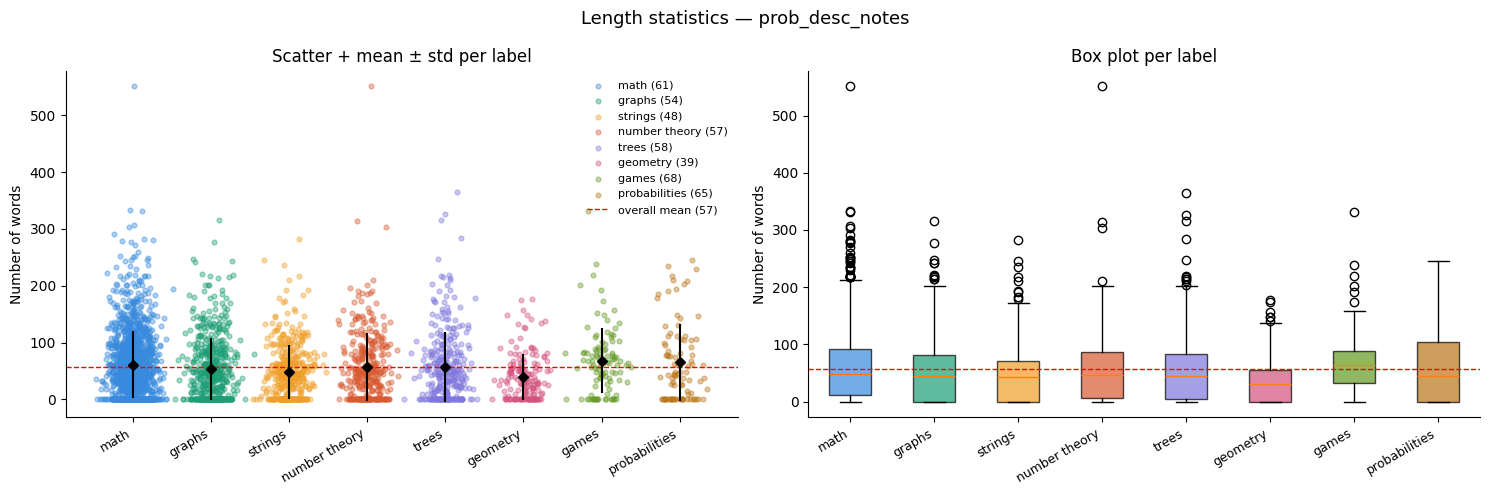


Saved → length_stats_prob_desc_notes.png


([('math', np.int64(45)),
  ('math', np.int64(35)),
  ('math', np.int64(136)),
  ('math', np.int64(0)),
  ('math', np.int64(16)),
  ('math', np.int64(52)),
  ('math', np.int64(35)),
  ('math', np.int64(173)),
  ('math', np.int64(52)),
  ('math', np.int64(9)),
  ('math', np.int64(68)),
  ('math', np.int64(81)),
  ('math', np.int64(69)),
  ('math', np.int64(153)),
  ('math', np.int64(112)),
  ('math', np.int64(25)),
  ('math', np.int64(144)),
  ('math', np.int64(171)),
  ('math', np.int64(0)),
  ('math', np.int64(80)),
  ('math', np.int64(0)),
  ('math', np.int64(32)),
  ('math', np.int64(65)),
  ('math', np.int64(88)),
  ('math', np.int64(124)),
  ('math', np.int64(38)),
  ('math', np.int64(121)),
  ('math', np.int64(0)),
  ('math', np.int64(59)),
  ('math', np.int64(61)),
  ('math', np.int64(24)),
  ('math', np.int64(51)),
  ('math', np.int64(121)),
  ('math', np.int64(49)),
  ('math', np.int64(130)),
  ('math', np.int64(44)),
  ('math', np.int64(46)),
  ('math', np.int64(47)),
  ('mat

In [8]:
compute_length_stats("prob_desc_notes")

In [9]:
def extract_value(raw):
    """Extract the first integer/float from a string like '256 megabytes' or '1 second'."""
    if isinstance(raw, (int, float)):
        return float(raw)
    match = re.search(r"[\d.]+", str(raw))
    return float(match.group()) if match else None


def compute_numeric_stats(domain):
    all_values = []   # (label, value)
    label_stats = {}

    for label in LABEL_TO_ID:
        files = fetch_files_per_label(label)
        values = []
        for fname in files:
            with open(os.path.join(DATA_DIR, fname),encoding="utf-8") as f:
                rec = json.load(f)
            raw = rec.get(domain)
            val = extract_value(raw)
            if val is not None:
                values.append(val)

        values = np.array(values)
        label_stats[label] = {
            "mean":  values.mean(),
            "std":   values.std(),
            "min":   values.min(),
            "max":   values.max(),
            "count": len(values),
        }
        all_values.extend([(label, v) for v in values])

    overall_arr = np.array([v for _, v in all_values])
    overall = {
        "mean":  overall_arr.mean(),
        "std":   overall_arr.std(),
        "min":   overall_arr.min(),
        "max":   overall_arr.max(),
        "count": len(overall_arr),
    }

    # ── print ─────────────────────────────────────────────────────────────
    print(f"\nDomain: {domain}")
    print(f"{'label':<18} {'count':>6} {'mean':>8} {'std':>8} {'min':>6} {'max':>6}")
    print("-" * 56)
    for label, s in label_stats.items():
        print(f"{label:<18} {s['count']:>6} {s['mean']:>8.1f} {s['std']:>8.1f} {s['min']:>6.0f} {s['max']:>6.0f}")
    print("-" * 56)
    print(f"{'OVERALL':<18} {overall['count']:>6} {overall['mean']:>8.1f} {overall['std']:>8.1f} {overall['min']:>6.0f} {overall['max']:>6.0f}")

    # ── plots ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Numeric stats — {domain}", fontsize=13)

    ax = axes[0]
    for label, label_id in LABEL_TO_ID.items():
        vals = [v for lbl, v in all_values if lbl == label]
        x = np.random.normal(label_id, 0.15, size=len(vals))
        ax.scatter(x, vals, c=COLORS[label_id], alpha=0.4, s=12, label=label)
        s = label_stats[label]
        ax.errorbar(label_id, s["mean"], yerr=s["std"],
                    fmt="D", color="black", markersize=5, linewidth=1.5, zorder=5)

    ax.axhline(overall["mean"], color="red", linestyle="--", linewidth=1,
               label=f"overall mean ({overall['mean']:.1f})")
    ax.set_xticks(list(LABEL_TO_ID.values()))
    ax.set_xticklabels(list(LABEL_TO_ID.keys()), rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(domain)
    ax.set_title("Scatter + mean ± std per label")
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    ax2 = axes[1]
    data_per_label = [[v for lbl, v in all_values if lbl == label]
                      for label in LABEL_TO_ID]
    bp = ax2.boxplot(data_per_label, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.axhline(overall["mean"], color="red", linestyle="--", linewidth=1)
    ax2.set_xticks(range(1, len(LABEL_TO_ID) + 1))
    ax2.set_xticklabels(list(LABEL_TO_ID.keys()), rotation=30, ha="right", fontsize=9)
    ax2.set_ylabel(domain)
    ax2.set_title("Box plot per label")
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"numeric_stats_{domain}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → numeric_stats_{domain}.png")

    return all_values, label_stats, overall





Domain: difficulty
label               count     mean      std    min    max
--------------------------------------------------------
math                 1392   1631.0    602.5     -1   3500
graphs                541   2007.0    450.2     -1   3500
strings               420   1560.0    526.7     -1   3200
number theory         345   1786.1    559.6    800   3500
trees                 323   2054.2    390.1    900   3100
geometry              164   1925.0    588.2    800   3500
games                 102   1789.2    603.7    800   3500
probabilities          91   2236.3    398.8   1300   3200
--------------------------------------------------------
OVERALL              3378   1774.1    576.5     -1   3500


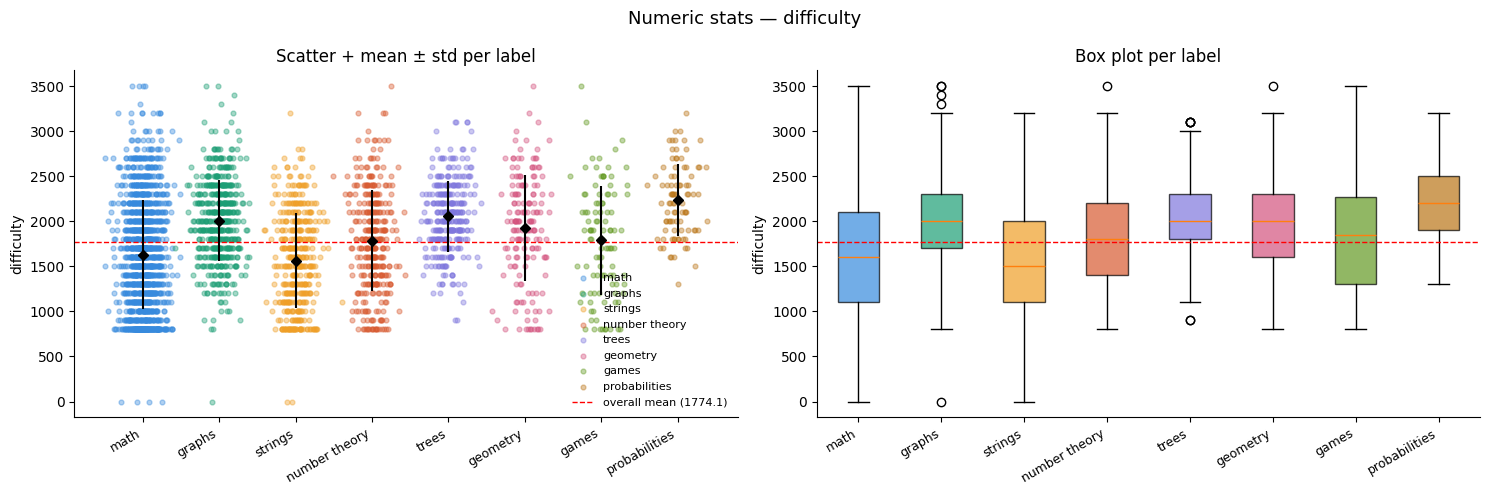

Saved → numeric_stats_difficulty.png

Domain: prob_desc_time_limit
label               count     mean      std    min    max
--------------------------------------------------------
math                 1408      1.7      1.0      0     10
graphs                542      2.1      1.2      1     15
strings               422      1.7      0.7      0      8
number theory         350      2.0      1.2      0     10
trees                 324      2.2      1.2      1     10
geometry              166      1.8      0.9      0      8
games                 105      1.8      0.8      1      5
probabilities          92      2.3      1.1      0      7
--------------------------------------------------------
OVERALL              3409      1.9      1.1      0     15


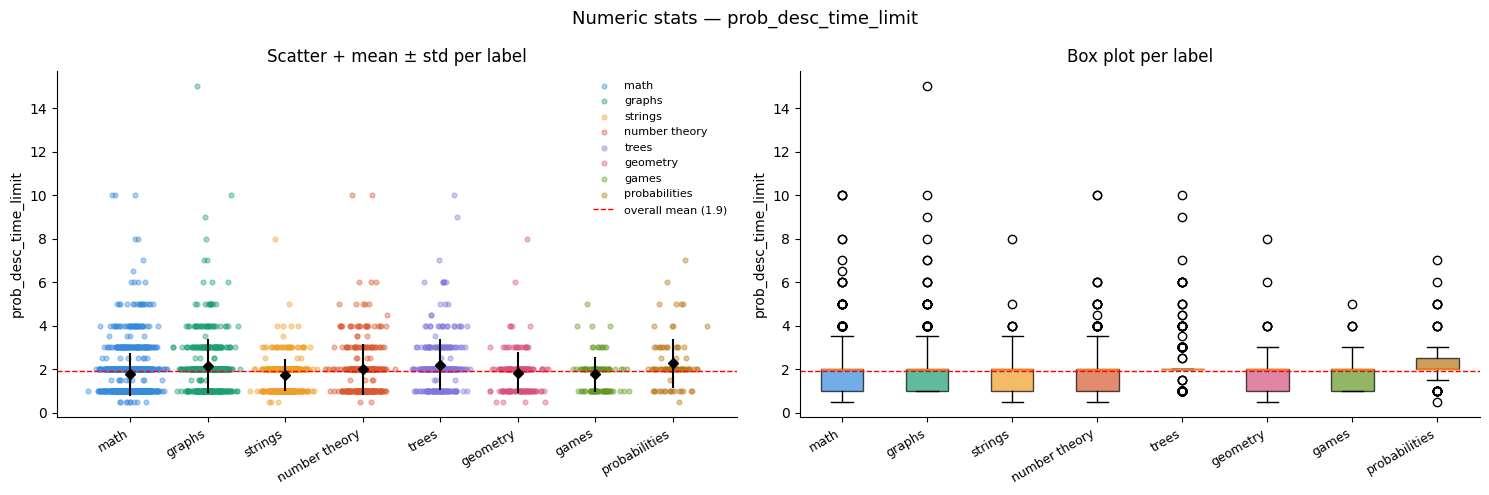

Saved → numeric_stats_prob_desc_time_limit.png

Domain: prob_desc_memory_limit
label               count     mean      std    min    max
--------------------------------------------------------
math                 1408    277.7     86.8     16   1024
graphs                542    281.4     95.6     32   1024
strings               422    278.3     87.7     64   1024
number theory         350    285.9    113.8     32   1024
trees                 324    293.9    108.6     64   1024
geometry              166    261.4     73.5     64    512
games                 105    269.4     69.9     64    512
probabilities          92    274.1     69.6    128    512
--------------------------------------------------------
OVERALL              3409    279.6     92.5     16   1024


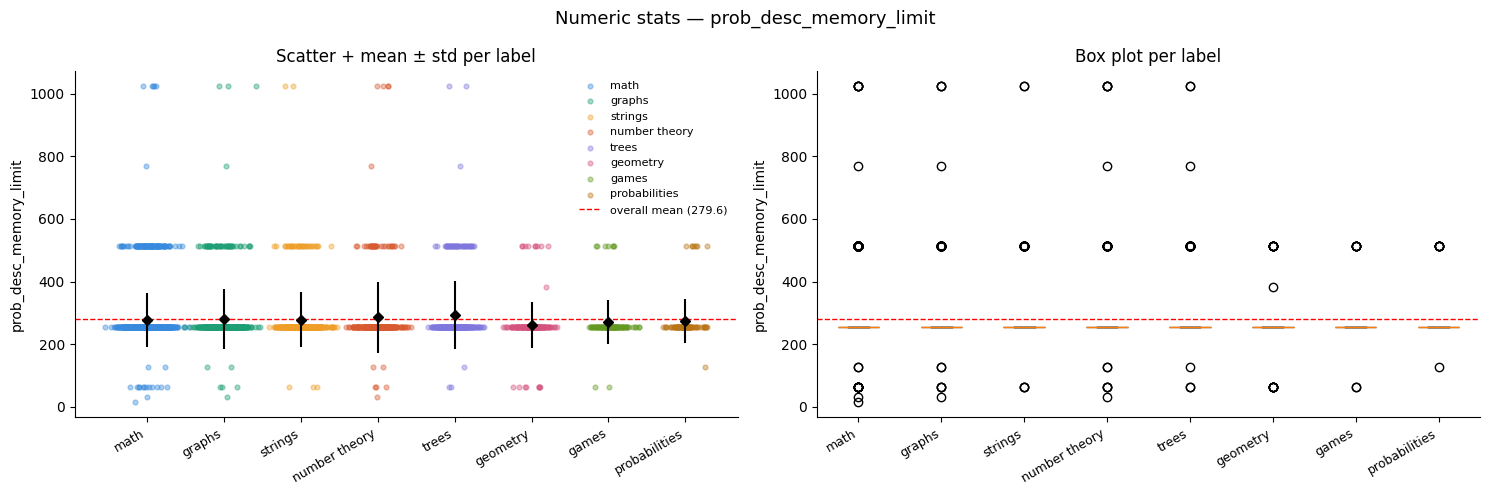

Saved → numeric_stats_prob_desc_memory_limit.png


([('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(512.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(256.0)),
  ('math', np.float64(512.0)),
  ('math

In [10]:
compute_numeric_stats("difficulty"              )
compute_numeric_stats("prob_desc_time_limit"    )
compute_numeric_stats("prob_desc_memory_limit"  )

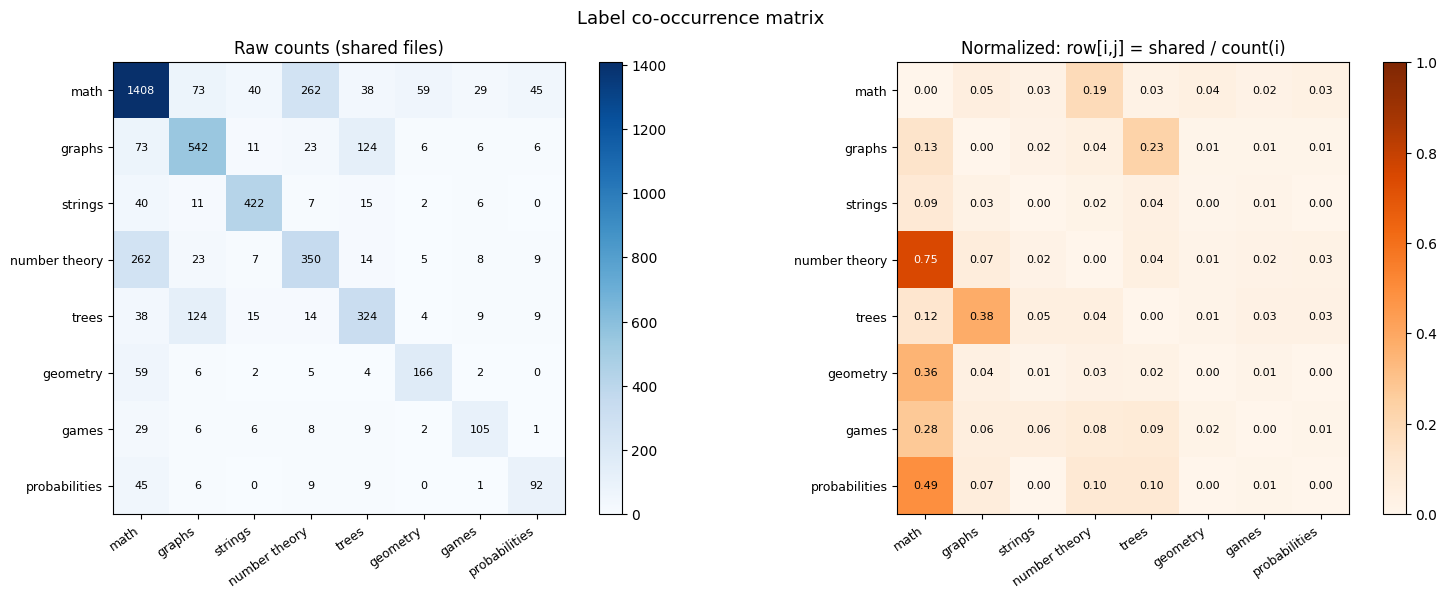

Saved → cooccurrence_matrix.png


In [11]:

LABELS = [
    "math", "graphs", "strings", "number theory",
    "trees", "geometry", "games", "probabilities"
]

def compute_cooccurrence(N=500):
    # collect all unique files per label (no sampling limit for accuracy)
    label_to_files = {}
    for label in LABELS:
        with open("label_index.json") as f:
            index = json.load(f)
        label_to_files[label] = set(index[label]["files"])

    n = len(LABELS)
    matrix = np.zeros((n, n), dtype=int)

    for i, label_a in enumerate(LABELS):
        for j, label_b in enumerate(LABELS):
            # intersection: files that appear in both labels
            shared = label_to_files[label_a] & label_to_files[label_b]
            matrix[i, j] = len(shared)

    return matrix


def plot_cooccurrence(matrix):
    n = len(LABELS)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Label co-occurrence matrix", fontsize=13)

    # ── raw counts ────────────────────────────────────────────────────────
    ax = axes[0]
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(LABELS, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(LABELS, fontsize=9)
    ax.set_title("Raw counts (shared files)")
    plt.colorbar(im, ax=ax)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(matrix[i, j]),
                    ha="center", va="center", fontsize=8,
                    color="white" if matrix[i, j] > matrix.max() * 0.6 else "black")

    # ── normalized (exclude diagonal) ─────────────────────────────────────
    ax2 = axes[1]
    norm = matrix.astype(float).copy()
    diag = np.diag(norm).copy()
    np.fill_diagonal(norm, 0)
    # normalize each row by the label's own file count (diagonal)
    for i in range(n):
        if diag[i] > 0:
            norm[i] /= diag[i]
    im2 = ax2.imshow(norm, cmap="Oranges", vmin=0, vmax=1)
    ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
    ax2.set_xticklabels(LABELS, rotation=35, ha="right", fontsize=9)
    ax2.set_yticklabels(LABELS, fontsize=9)
    ax2.set_title("Normalized: row[i,j] = shared / count(i)")
    plt.colorbar(im2, ax=ax2)
    for i in range(n):
        for j in range(n):
            ax2.text(j, i, f"{norm[i,j]:.2f}",
                     ha="center", va="center", fontsize=8,
                     color="white" if norm[i, j] > 0.6 else "black")

    plt.tight_layout()
    plt.savefig("cooccurrence_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → cooccurrence_matrix.png")


if __name__ == "__main__":
    matrix = compute_cooccurrence()
    plot_cooccurrence(matrix)